In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 11

def stats_vs_scalar_baseline(ours_scores, baseline_scalar, alpha=0.05, greater_is_better=True):
    x = np.asarray(ours_scores, dtype=float)
    b = float(baseline_scalar)
    if x.ndim != 1:
        raise ValueError("ours_scores must be 1D.")

    diff = (x - b) if greater_is_better else (b - x)  # improvement if >0

    if diff.size >= 3:
        _, shapiro_p = stats.shapiro(diff)
        normal = (shapiro_p > alpha)
    else:
        shapiro_p = np.nan
        normal = False

    if normal:
        test = "one-sample one-sided t-test"
        try:
            res = stats.ttest_1samp(diff, 0.0, alternative="greater")
            p = float(res.pvalue)
            stat = float(res.statistic)
        except TypeError:
            res = stats.ttest_1samp(diff, 0.0)
            stat = float(res.statistic)
            df = diff.size - 1
            p = float(stats.t.sf(stat, df))
    else:
        test = "Wilcoxon signed-rank (one-sided)"
        if np.allclose(diff, 0.0):
            stat, p = 0.0, 1.0
        else:
            res = stats.wilcoxon(diff, alternative="greater", zero_method="wilcox")
            stat, p = float(res.statistic), float(res.pvalue)

    return {
        "diff": diff,
        "diff_mean": float(np.mean(diff)),
        "shapiro_p": float(shapiro_p) if shapiro_p is not None else float("nan"),
        "normality_passed": bool(normal),
        "test": test,
        "statistic": stat,
        "p_value": p,
        "baseline": b
    }


def _kde_curve(x, grid=None):
    """Seaborn 없이 KDE 곡선(gaussian_kde)"""
    x = np.asarray(x, dtype=float)
    if x.size < 2 or np.allclose(x, x[0]):
        return None, None
    kde = stats.gaussian_kde(x)
    if grid is None:
        pad = 0.05 * (x.max() - x.min() + 1e-12)
        grid = np.linspace(x.min() - pad, x.max() + pad, 200)
    y = kde(grid)
    return grid, y


def plot_hist_box_with_baseline(
    ours_scores,
    baseline_scalar,
    alpha=0.05,
    greater_is_better=True,
    metric_name="Accuracy(%)",
    bins=6,
    show_kde=True,
    title_prefix=None,
    filename=None
):
    """
    너가 올린 스타일:
      Left : histogram + (optional) KDE, baseline vertical dashed line
      Right: boxplot, baseline vertical dashed line
    """
    x = np.asarray(ours_scores, dtype=float)
    b = float(baseline_scalar)

    res = stats_vs_scalar_baseline(x, b, alpha=alpha, greater_is_better=greater_is_better)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=120)

    # --- Left: histogram ---
    ax1.hist(x, bins=bins, alpha=0.35, edgecolor="black")
    if show_kde:
        grid, y = _kde_curve(x)
        if grid is not None:
            # 히스토그램 스케일에 맞추려고 area 정규화 대신 "대충" 스케일: 최대높이에 맞춤
            hist_counts, _ = np.histogram(x, bins=bins)
            if hist_counts.max() > 0 and y.max() > 0:
                y_scaled = y * (hist_counts.max() / y.max())
                ax1.plot(grid, y_scaled, linewidth=2.0)

    ax1.axvline(b, linestyle="--", linewidth=2.0, color="red", label=f"baseline = {b:.3g}")
    ax1.set_xlabel(metric_name)
    ax1.set_ylabel("Frequency")
    ax1.legend(loc="upper right", frameon=True)

    # --- Right: boxplot ---
    ax2.boxplot(x, vert=False, widths=0.6, patch_artist=True,
                boxprops=dict(alpha=0.5),
                medianprops=dict(linewidth=2.0),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
    ax2.axvline(b, linestyle="--", linewidth=2.0, color="red")
    ax2.set_xlabel(metric_name)
    ax2.set_yticks([])

    # --- Title (stats) ---
    # ttl = (
    #     f"Shapiro p={res['shapiro_p']:.3g} | {res['test']} p={res['p_value']:.3g} | mean(Δ)={res['diff_mean']:.4g}"
    #     f"\n(H1: improvement > 0; α={alpha})"
    # )
    # if title_prefix:
    #     ttl = f"{title_prefix}\n{ttl}"
    # fig.suptitle(ttl, y=1.05, fontsize=10)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=1200, bbox_inches="tight")
    return res



{'diff': array([0.00171975, 0.0002535 , 0.00125425, 0.0011765 , 0.000451  ,
       0.002235  , 0.0016155 ]), 'diff_mean': 0.0012436428571428776, 'shapiro_p': 0.7697475248979824, 'normality_passed': True, 'test': 'one-sample one-sided t-test', 'statistic': 4.683805467872723, 'p_value': 0.0016912642535845735, 'baseline': 0.281}


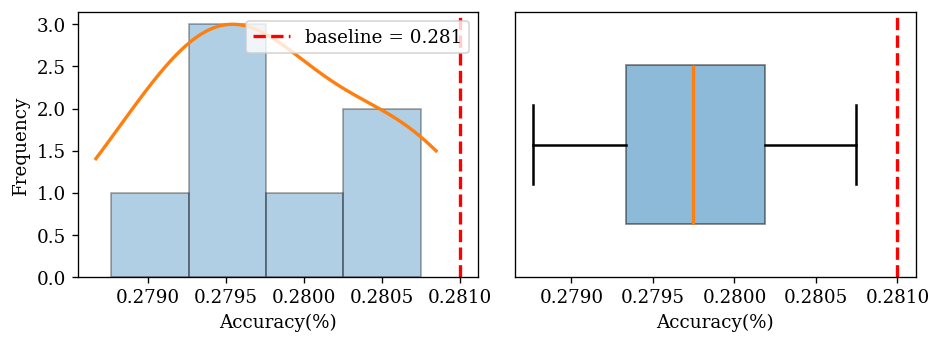

In [19]:

# -----------------------
# ETTm2
# -----------------------
ours_720 = [0.400749,0.404128, 0.401572, 0.401036, 0.401596, 0.400979, 0.398896]
ours_336 = [0.301436,0.302936, 0.302272, 0.301351, 0.305320, 0.300554, 0.301941]
ours_192 = [0.239707,0.240792, 0.240159, 0.241584, 0.239541, 0.238873, 0.241495]
ours_96 = [0.175229,0.175130, 0.174980, 0.175323, 0.175739, 0.174654, 0.175206]
ours = np.array(ours_720) + np.array(ours_192) + np.array(ours_336) + np.array(ours_96)
ours /=4
baseline = 0.281
res = plot_hist_box_with_baseline(
    ours_scores=ours,
    baseline_scalar=baseline,
    alpha=0.05,
    greater_is_better=False,
    metric_name="Accuracy(%)",
    bins=4,
    show_kde=True,
    title_prefix="ETTm2",
    filename="ETTm2_hist_box.pdf"
)
print(res)


{'diff': array([0.00503125, 0.00779875, 0.00814525, 0.003102  , 0.0086535 ,
       0.007251  , 0.00841875]), 'diff_mean': 0.0069143571428571604, 'shapiro_p': 0.07183483726013395, 'normality_passed': True, 'test': 'one-sample one-sided t-test', 'statistic': 8.825660090151692, 'p_value': 5.876439081353605e-05, 'baseline': 0.388}


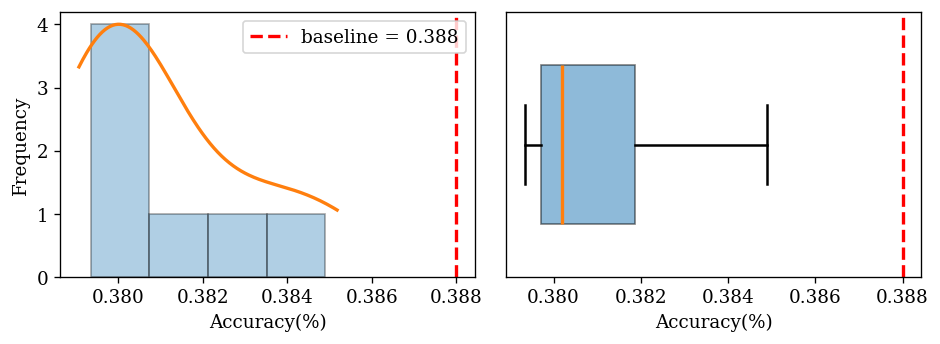

In [18]:

# -----------------------
# ETTm1
# -----------------------
ours_720 = [0.454525,0.451537,0.456227, 0.450530,0.451284,0.445445, 0.446342]
ours_336 = [0.394678,0.390818,0.387074,0.392467, 0.391344, 0.390544, 0.390396]
ours_192 = [0.365411,0.364309, 0.359291, 0.368556, 0.360896, 0.371705, 0.364242]
ours_96 = [0.317261,0.314141, 0.316827, 0.328039, 0.313862, 0.315302, 0.317345]
ours = np.array(ours_720) + np.array(ours_192) + np.array(ours_336) + np.array(ours_96)
ours /=4
baseline = 0.388
res = plot_hist_box_with_baseline(
    ours_scores=ours,
    baseline_scalar=baseline,
    alpha=0.05,
    greater_is_better=False,
    metric_name="Accuracy(%)",
    bins=4,
    show_kde=True,
    title_prefix="ETTm1",
    filename="ETTm1_hist_box.pdf"
)
print(res)


In [ ]:

# -----------------------
# ETTm2
# -----------------------
ours_720 = [0.454525,0.451537,0.456227, 0.450530,0.451284,0.445445, 0.446342]
ours_336 = [0.394678,0.390818,0.387074,0.392467, 0.391344, 0.390544, 0.390396]
ours_192 = [0.365411,0.364309, 0.359291, 0.368556, 0.360896, 0.371705, 0.364242]
ours_96 = [0.317261,0.314141, 0.316827, 0.328039, 0.313862, 0.315302, 0.317345]
ours = np.array(ours_720) + np.array(ours_192) + np.array(ours_336) + np.array(ours_96)
ours /=4
baseline = 0.281
res = plot_hist_box_with_baseline(
    ours_scores=ours,
    baseline_scalar=baseline,
    alpha=0.05,
    greater_is_better=False,
    metric_name="Accuracy(%)",
    bins=4,
    show_kde=True,
    title_prefix="ETTm2",
    filename="ETTm2_hist_box.pdf"
)
print(res)
